In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import re
import os
import glob
import sys
from tqdm import tqdm
import datetime
import gc
import numpy as np
import tensorflow as tf

In [3]:
config = {
    'project_path': 'drive/MyDrive/author-handwriting-recog',
    'dataset': 'complete_dataset_20260122-142244.tar.gz',
    'authors_range': range(50),
    'input_shape': (60, 53, 1),
    'embedding_dim': 256,
    'epochs': 8
}

In [4]:
sys.path.insert(0, config['project_path'])

In [5]:
sys.path

['drive/MyDrive/author-handwriting-recog',
 '/content',
 '/env/python',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/usr/local/lib/python3.12/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/IPython/extensions',
 '/root/.ipython']

In [6]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 111.2 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=1a44225afaa181a803b593a1159813bea7ab1d08fbca6226c40bee6ca89f4fd9
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [7]:
from src.io.exceptions import DeserializationError
from src.io.logging import LoggerFactory
from src import SelectiveDataLoader
from src.io import load

In [8]:
dataset_path = f"{config['project_path']}/data/datasets/{config['dataset']}"

In [9]:
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

In [10]:
logger = LoggerFactory.get_notebook_logger("code_1", log_dir=f"./logs_{current_time}")

In [11]:
!tar -xzf {dataset_path} -C ./

In [12]:
loader = SelectiveDataLoader(
        dataset_path="./complete_dataset_20260122-142244.zarr",
        load_fn=load
        )

12:49:21 - ZarrSerializer - INFO - Initialized with blosc compression (level 5)
12:49:21 - ZarrSerializer - INFO - ======================================================================
12:49:21 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
12:49:21 - ZarrSerializer - INFO - ======================================================================
12:49:21 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
12:49:21 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
12:49:21 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
12:49:21 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
12:49:21 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
12:49:21 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
12:49:21 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
12:49:21 - ZarrSerializer - INFO - ======================

In [13]:
from src.datasets import DataInitializer, PatchNormalizer, SubsetBuilder

In [14]:
normalizer = PatchNormalizer()

In [15]:
subset_builder = SubsetBuilder(
    loader=loader,
    data_normalizer=normalizer
)

In [16]:
subset = subset_builder.build(
    authors_range=config['authors_range'],
    show_progress_bar=True,
)

12:49:21 - ZarrSerializer - INFO - ======================================================================
12:49:21 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
12:49:21 - ZarrSerializer - INFO - ======================================================================
12:49:21 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
12:49:21 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
12:49:21 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
12:49:21 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
12:49:21 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
12:49:21 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
12:49:21 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
12:49:21 - ZarrSerializer - INFO - ======================================================================
12:49:21 - ZarrSerializer - INF

Building subset dataset: 100%|██████████| 150/150 [00:22<00:00,  6.61it/s]


In [17]:
subset.keys()

dict_keys(['train', 'validation', 'test'])

In [18]:
from src.datasets import PairGenerator

In [19]:
train_gen = PairGenerator(
    data=subset['train'].data,
    authors_ids=subset['train'].authors_ids,
    valid_authors=subset['train'].valid_authors,
    batch_size=64,
    shuffle=True,
    use_augmentation=True,
    seed=42
)

In [20]:
val_gen = PairGenerator(
    data=subset['validation'].data,
    authors_ids=subset['validation'].authors_ids,
    valid_authors=subset['validation'].valid_authors,
    batch_size=32,
    use_augmentation=False,
    shuffle=False,
)

In [21]:
test_gen = PairGenerator(
    data=subset['test'].data,
    authors_ids=subset['test'].authors_ids,
    valid_authors=subset['test'].valid_authors,
    batch_size=8,
    use_augmentation=False,
    shuffle=False,
)

In [22]:
len(train_gen), len(val_gen), len(test_gen)

(2402, 780, 776)

In [23]:
logger.info(f"Train samples: {train_gen.num_patches}")
logger.info(f"Validation samples: {val_gen.num_patches}")
logger.info(f"Test samples: {test_gen.num_patches}")
logger.info(f"Ratio: {train_gen.num_patches / val_gen.num_patches:.2f}")

INFO - Train samples: 153701
INFO - Validation samples: 24954
INFO - Test samples: 6201
INFO - Ratio: 6.16


In [24]:
logger.info(f"Train augmentation: {train_gen.augmenter is not None}")
logger.info(f"Val augmentation: {val_gen.augmenter is not None}")
logger.info(f"Test augmentation: {test_gen.augmenter is not None}")

INFO - Train augmentation: True
INFO - Val augmentation: False
INFO - Test augmentation: False


In [25]:
train_stats = train_gen.get_statistics()
logger.info(f"Train samples: {train_stats["total_patches"]}")
logger.info(f"Avg patches per author: {train_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {train_stats["min_patches"]}")
logger.info(f"Max patches per author: {train_stats["max_patches"]}")

INFO - Train samples: 153701
INFO - Avg patches per author: 3074.02
INFO - Min patches per author: 792
INFO - Max patches per author: 3185


In [26]:
val_stats = val_gen.get_statistics()
logger.info(f"Val samples: {val_stats["total_patches"]}")
logger.info(f"Avg patches per author: {val_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {val_stats["min_patches"]}")
logger.info(f"Max patches per author: {val_stats["max_patches"]}")

INFO - Val samples: 24954
INFO - Avg patches per author: 499.08
INFO - Min patches per author: 143
INFO - Max patches per author: 523


In [27]:
test_stats = test_gen.get_statistics()
logger.info(f"Val samples: {test_stats["total_patches"]}")
logger.info(f"Avg patches per author: {test_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {test_stats["min_patches"]}")
logger.info(f"Max patches per author: {test_stats["max_patches"]}")

INFO - Val samples: 6201
INFO - Avg patches per author: 124.02
INFO - Min patches per author: 97
INFO - Max patches per author: 142


In [28]:
from src.models import (
    CNNBackbone,
    CNNTransformerBackbone,
    DeepCNNBackbone,
    build_siamese_model,
    build_embedding_model,
    ContrastiveLoss,
    BinaryCrossEntropyDistance,
)
from src.models.training import ModelTrainer, get_default_callbacks
from src.models.evaluation import (
    ModelComparator,
    ModelEvaluator,
    plot_training_history,
    plot_comparison_metrics,
    plot_embeddings_tsne
)

In [27]:
backbone = DeepCNNBackbone()

In [28]:
cnn_trainer = ModelTrainer(
    backbone=backbone,
    input_shape=config['input_shape'],
    embedding_dim=256,
    model_name="siamese_cnn",
    log_dir=f"./logs_{current_time}"
)

05:16:40 - siamese_cnn_trainer - INFO - Model trainer initialized: siamese_cnn
05:16:40 - siamese_cnn_trainer - INFO - Input shape: (60, 53, 1)
05:16:40 - siamese_cnn_trainer - INFO - Embedding dim: 256


In [29]:
cnn_trainer.build()

05:17:03 - siamese_cnn_trainer - INFO - Building models...
05:17:05 - siamese_cnn_trainer - INFO - Model built: siamese_model
05:17:05 - siamese_cnn_trainer - INFO - Total params: 3391296
05:17:05 - siamese_cnn_trainer - INFO - Trainable params: 3388544


In [31]:
cnn_trainer.embedding_model.summary()

Model: "siamese_cnn_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 53, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 60, 53, 96)     │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 53, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 60, 53, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 26, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 30, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 15, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 6, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 7, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 6, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 7, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 256)            │        65,79

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [32]:
cnn_trainer.siamese_model.summary()

Model: "siamese_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image1 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image2 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ siamese_cnn_embedd… │ (None, 256)       │  3,391,296 │ image1[0][0],     │
│ (Functional)        │                   │            │ image2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 2, 256)    │          0 │ siamese_cnn_embe… │
│                     │                   │            │ siamese_cnn_embe… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [33]:
cnn_trainer.compile(loss=ContrastiveLoss(margin=1.0))

05:18:22 - siamese_cnn_trainer - INFO - Compiling model...
05:18:22 - siamese_cnn_trainer - INFO - Model compiled
05:18:22 - siamese_cnn_trainer - INFO -   - Optimizer: Adam
05:18:22 - siamese_cnn_trainer - INFO -   - Learning rate: 0.0001
05:18:22 - siamese_cnn_trainer - INFO -   - Loss: ContrastiveLoss
05:18:22 - siamese_cnn_trainer - INFO -   - Loss margin: 1.0


In [34]:
callbacks = get_default_callbacks(
    model_name="siamese_cnn",
    patience=4,
    reduce_lr_patience=2,
)

In [35]:
cnn_history = cnn_trainer.train(
    train_generator=train_gen,
    val_generator=val_gen,
    epochs=config['epochs'],
    callbacks=callbacks,
    verbose=1
)

05:18:45 - siamese_cnn_trainer - INFO - Starting training for 8 epochs...
05:18:45 - siamese_cnn_trainer - INFO -   - Train batches: 2402
05:18:45 - siamese_cnn_trainer - INFO -   - Val batches: 780
Epoch 1/8
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.2506
Epoch 1: val_loss improved from inf to 0.24141, saving model to checkpoints/siamese_cnn/best.keras
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 335s 133ms/step - loss: 0.2506 - val_loss: 0.2414 - learning_rate: 1.0000e-04
Epoch 2/8
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.2377
Epoch 2: val_loss improved from 0.24141 to 0.23631, saving model to checkpoints/siamese_cnn/best.keras
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 317s 132ms/step - loss: 0.2377 - val_loss: 0.2363 - learning_rate: 1.0000e-04
Epoch 3/8
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.2361
Epoch 3: val_loss improved from 0.23631 to 0.22638, saving model to checkpoints/siamese_cnn/best.keras
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 344s 143ms/step - loss: 0.2361 - val_

In [81]:
import matplotlib.pyplot as plt

def plot_training_loss(history, title="Training Loss"):
    loss = history.history["loss"]
    val_loss = history.history.get("val_loss")

    plt.figure(figsize=(8, 5))
    plt.plot(loss, label="Train Loss")
    if val_loss is not None:
        plt.plot(val_loss, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

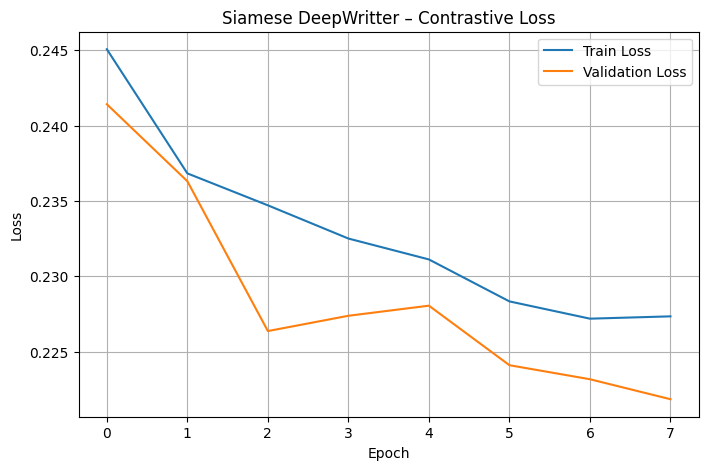

In [83]:
plot_training_loss(
    cnn_history,
    title="Siamese DeepWritter – Contrastive Loss"
)

In [36]:
cnn_trainer.save(f"./models/siamese_cnn_{current_time}.keras")

06:03:17 - siamese_cnn_trainer - INFO - Model saved to models/siamese_cnn_20260129-051454.keras


In [ ]:
cnn_transformer_backbone = CNNTransformerBackbone()

In [ ]:
transformer_trainer = ModelTrainer(
    backbone=cnn_transformer_backbone,
    input_shape=config['input_shape'],
    embedding_dim=config['embedding_dim'],
    model_name="siamese_cnn_transformer",
    log_dir=f"./logs_{current_time}"
)

09:13:23 - siamese_cnn_transformer_trainer - INFO - Model trainer initialized: siamese_cnn_transformer
09:13:23 - siamese_cnn_transformer_trainer - INFO - Input shape: (60, 53, 1)
09:13:23 - siamese_cnn_transformer_trainer - INFO - Embedding dim: 256


In [ ]:
transformer_trainer.build()
transformer_trainer.compile()

09:13:29 - siamese_cnn_transformer_trainer - INFO - Building models...
09:13:30 - siamese_cnn_transformer_trainer - INFO - Model built: siamese_model
09:13:30 - siamese_cnn_transformer_trainer - INFO - Total params: 3087232
09:13:30 - siamese_cnn_transformer_trainer - INFO - Trainable params: 3086272
09:13:30 - siamese_cnn_transformer_trainer - INFO - Compiling model...
09:13:30 - siamese_cnn_transformer_trainer - INFO - Model compiled
09:13:30 - siamese_cnn_transformer_trainer - INFO -   - Optimizer: Adam
09:13:30 - siamese_cnn_transformer_trainer - INFO -   - Learning rate: 0.0001
09:13:30 - siamese_cnn_transformer_trainer - INFO -   - Loss: BinaryCrossEntropyDistance
09:13:30 - siamese_cnn_transformer_trainer - INFO -   - Loss scale: 10.0


In [ ]:
transformer_history = transformer_trainer.train(
    train_generator=train_gen,
    val_generator=val_gen,
    epochs=8,
    verbose=1
)

09:14:06 - siamese_cnn_transformer_trainer - INFO - Starting training for 8 epochs...
09:14:06 - siamese_cnn_transformer_trainer - INFO -   - Train batches: 2402
09:14:06 - siamese_cnn_transformer_trainer - INFO -   - Val batches: 780
Epoch 1/8
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.7275
Epoch 1: val_loss improved from inf to 0.68366, saving model to checkpoints/siamese_cnn_transformer/best.keras
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 454s 180ms/step - loss: 0.7275 - val_loss: 0.6837 - learning_rate: 1.0000e-04
Epoch 2/8
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - loss: 0.6875
Epoch 2: val_loss did not improve from 0.68366
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 422s 175ms/step - loss: 0.6875 - val_loss: 0.6842 - learning_rate: 1.0000e-04
Epoch 3/8
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 0.6857
Epoch 3: val_loss did not improve from 0.68366
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 419s 174ms/step - loss: 0.6857 - val_loss: 0.6841 - learning_rate: 1.0000e-04
Epoch 4/8
2402/2402 ━━━

In [ ]:
transformer_trainer.save(f"./models/siamese_transformer_{current_time}.keras")

10:10:49 - siamese_cnn_transformer_trainer - INFO - Model saved to models/siamese_transformer_20260128-081933.keras


In [62]:
import importlib
from src.models.evaluation import model_evaluator
importlib.reload(model_evaluator)

<module 'src.models.evaluation.model_evaluator' from '/content/drive/MyDrive/author-handwriting-recog/src/models/evaluation/model_evaluator.py'>

In [29]:
cnn_trainer_new = ModelTrainer(
    backbone=DeepCNNBackbone(),
    input_shape=(60, 53, 1),
    embedding_dim=256,
    model_name="siamese_cnn",
    log_dir=f"./logs_{current_time}"
)

12:51:03 - siamese_cnn_trainer - INFO - Model trainer initialized: siamese_cnn
12:51:03 - siamese_cnn_trainer - INFO - Input shape: (60, 53, 1)
12:51:03 - siamese_cnn_trainer - INFO - Embedding dim: 256


In [30]:
cnn_trainer_new.build()

12:51:06 - siamese_cnn_trainer - INFO - Building models...
12:51:07 - siamese_cnn_trainer - INFO - Model built: siamese_model
12:51:07 - siamese_cnn_trainer - INFO - Total params: 3391296
12:51:07 - siamese_cnn_trainer - INFO - Trainable params: 3388544


In [31]:
cnn_trainer_new.siamese_model.load_weights(
    f"{config['project_path']}/data/datasets/experiments/models_50/siamese_cnn_20260129-051454.keras"
)

In [32]:
from src.models.evaluation.model_evaluator import ModelEvaluator

In [33]:
cnn_evaluator = ModelEvaluator(
    model=cnn_trainer_new.siamese_model,
    model_name="siamese_cnn",
    embedding_model=cnn_trainer_new.embedding_model,
    log_dir=f"./logs_{current_time}"
)

In [58]:
cnn_evaluator.model.summary()

Model: "siamese_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image1 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image2 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ siamese_cnn_embedd… │ (None, 256)       │  3,391,296 │ image1[0][0],     │
│ (Functional)        │                   │            │ image2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 2, 256)    │          0 │ siamese_cnn_embe… │
│                     │                   │            │ siamese_cnn_embe… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [59]:
cnn_evaluator.embedding_model.summary()

Model: "siamese_cnn_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 53, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 60, 53, 96)     │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 53, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 60, 53, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 26, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 30, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 15, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 6, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 7, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 6, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 7, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 256)            │        65,79

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [ ]:
transformer_evaluator = ModelEvaluator(
    model=transformer_trainer.siamese_model,
    model_name="siamese_transformer",
    log_dir=f"./logs_{current_time}"
)

In [ ]:
comparator = ModelComparator(
    evaluators_dict={
        'Siamese CNN': cnn_evaluator,
        'Siamese CNN + Transformer': transformer_evaluator
    },
    log_dir=f"./logs_{current_time}"
)

10:11:49 - model_comparator - INFO - Comparator initialized with 2 models


In [34]:
test_results = cnn_evaluator.evaluate(
    test_generator=test_gen,
    distance_threshold=0.52
)

12:51:36 - siamese_cnn_evaluator - INFO - Evaluating siamese_cnn...
12:52:38 - siamese_cnn_evaluator - INFO - Evaluation completed:
12:52:38 - siamese_cnn_evaluator - INFO -   - Accuracy:  0.6907
12:52:38 - siamese_cnn_evaluator - INFO -   - AUC:       0.8160
12:52:38 - siamese_cnn_evaluator - INFO -   - Precision: 0.6271
12:52:38 - siamese_cnn_evaluator - INFO -   - Recall:    0.9410
12:52:38 - siamese_cnn_evaluator - INFO -   - F1-Score:  0.7526


INFO - Positive pairs - mean: 0.3142, std: 0.1197
INFO - Negative pairs - mean: 0.4935, std: 0.1535


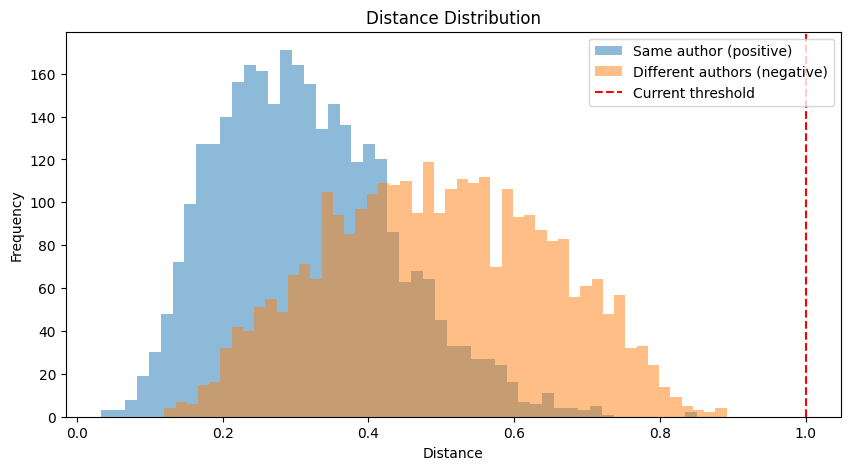

In [35]:
import matplotlib.pyplot as plt

distances = test_results['distances']
y_true = test_results['y_true']

pos_distances = distances[y_true == 1]
neg_distances = distances[y_true == 0]

logger.info(f"Positive pairs - mean: {pos_distances.mean():.4f}, std: {pos_distances.std():.4f}")
logger.info(f"Negative pairs - mean: {neg_distances.mean():.4f}, std: {neg_distances.std():.4f}")

# Plot histograma
plt.figure(figsize=(10, 5))
plt.hist(pos_distances, bins=50, alpha=0.5, label='Same author (positive)')
plt.hist(neg_distances, bins=50, alpha=0.5, label='Different authors (negative)')
plt.axvline(x=1.0, color='r', linestyle='--', label='Current threshold')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distance Distribution')
plt.show()

In [36]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, 1 - (distances / distances.max()))
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx] * distances.max()

logger.info(f"\nOptimal threshold: {optimal_threshold:.4f}")

INFO - 
Optimal threshold: 0.4743


In [75]:
import src.datasets
importlib.reload(src.datasets)

<module 'src.datasets' from '/content/drive/MyDrive/author-handwriting-recog/src/datasets/__init__.py'>

In [50]:
def resize_batch(X: np.ndarray, target_size=(60, 53)) -> np.ndarray:
    return tf.image.resize(
        X,
        target_size,
        method="bilinear"
    ).numpy()

In [51]:
X_test, y_test = subset['test'].flatten_data()

In [52]:
X_test.shape

(6201, 180, 160, 1)

In [53]:
X_test_resized = resize_batch(X_test)

In [54]:
X_test_resized.shape, y_test.shape

((6201, 60, 53, 1), (6201,))

In [55]:
len(subset['test'].authors_ids)

50

INFO - Embeddings shape: (6201, 256)
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 6201 samples in 0.001s...
[t-SNE] Computed neighbors for 6201 samples in 0.171s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed conditional probabilities for sample 1000 / 6201
[t-SNE] Computed conditional probabilities for sample 2000 / 6201
[t-SNE] Computed conditional probabilities for sample 3000 / 6201
[t-SNE] Computed conditional probabilities for sample 4000 / 6201
[t-SNE] Computed conditional probabilities for sample 5000 / 6201
[t-SNE] Computed conditional probabilities for sample 6000 / 6201
[t-SNE] Computed conditional probabilities for sample 6201 / 6201
[t-SNE] Mean sigma: 0.067813
[t-SNE] KL divergence after 250 iterations with early exaggeration: 81.855736
[t-SNE] KL divergence after 1000 iterations: 1.619042


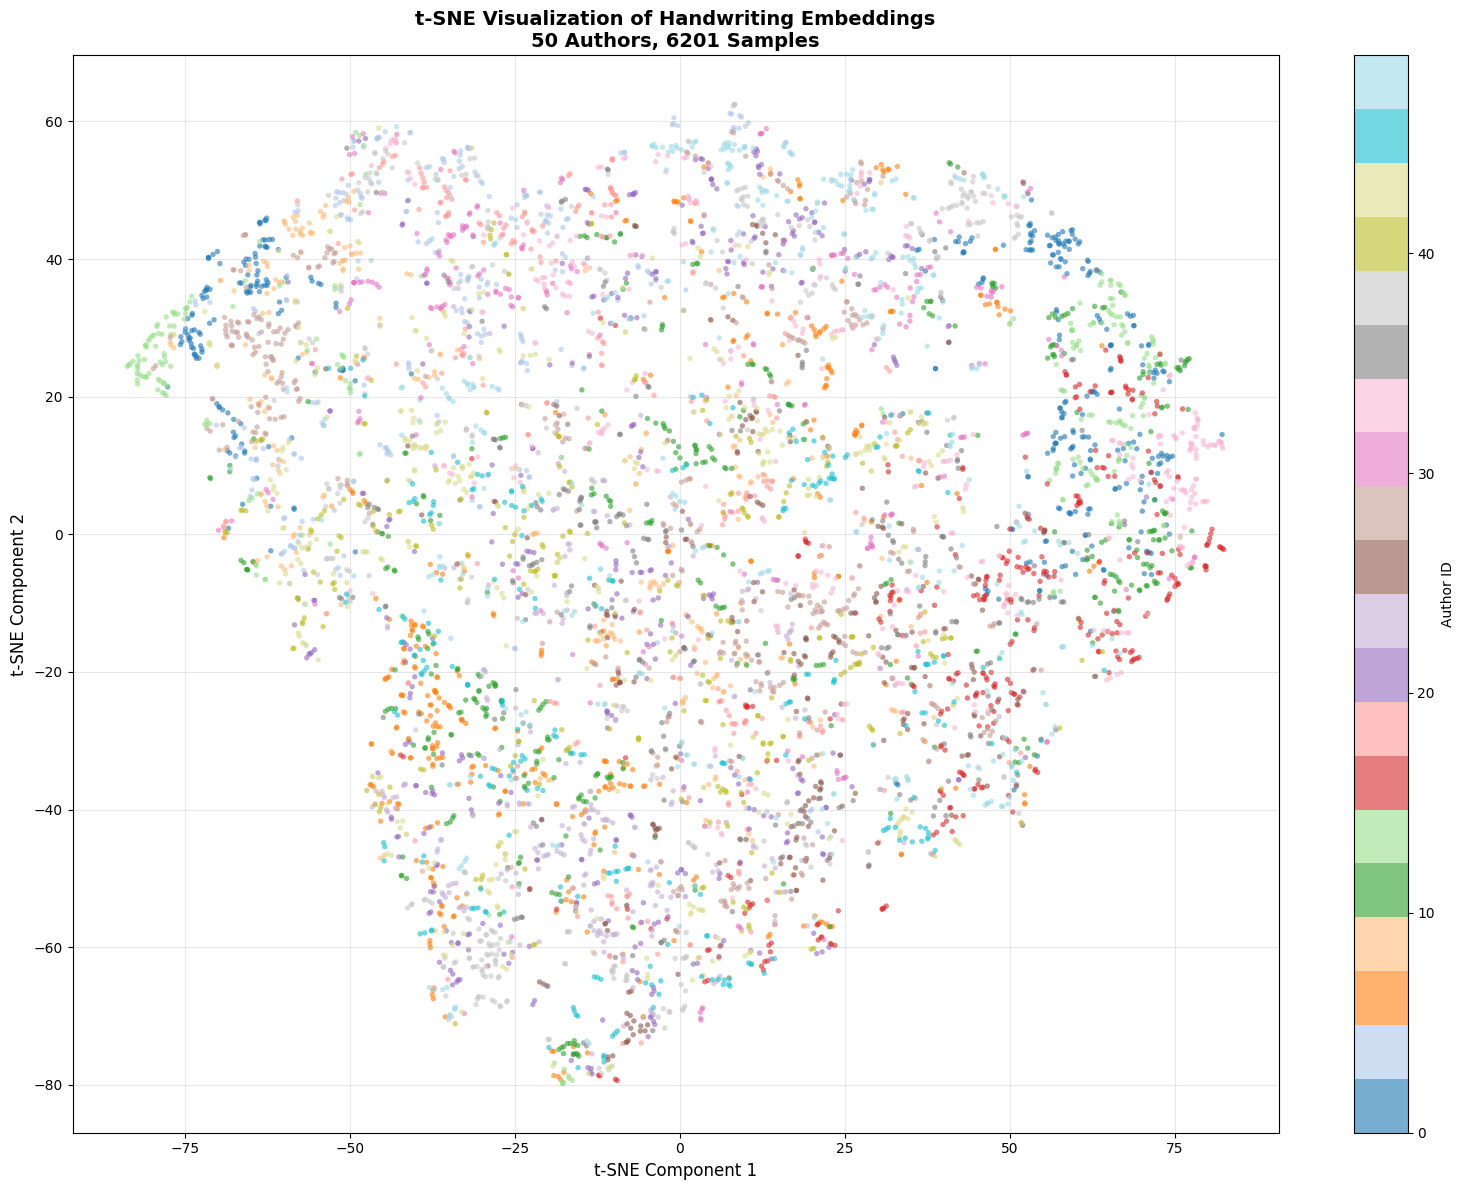

INFO - 
Visualization created for 50 authors


In [60]:
embeddings = cnn_evaluator.embedding_model.predict(X_test_resized, verbose=0)
logger.info(f"Embeddings shape: {embeddings.shape}")

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    n_iter=1000,
    verbose=1
)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(16, 12))
scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=y_test,           # Colorear por autor
    cmap='tab20',       # Paleta de colores
    alpha=0.6,
    s=15,
    edgecolors='none'
)
plt.colorbar(scatter, label='Author ID')
plt.title(f't-SNE Visualization of Handwriting Embeddings\n{len(np.unique(y_test))} Authors, {len(y_test)} Samples',
          fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

logger.info(f"\nVisualization created for {len(np.unique(y_test))} authors")

In [62]:
from collections import defaultdict

def build_test_data(
    X: np.ndarray,
    y: np.ndarray,
) -> dict[int, list[np.ndarray]]:

    test_data: dict[int, list[np.ndarray]] = defaultdict(list)

    for patch, author_id in zip(X, y):
        test_data[int(author_id)].append(patch)

    return dict(test_data)

In [63]:
test_data = build_test_data(X_test_resized, y_test)

In [67]:
def voting_for_author(
    embeddings: np.ndarray,
    distance_threshold: float,
) -> dict[str, float]:
    votes_same, votes_diff = 0, 0
    distances = []

    for i in range(len(embeddings)):
        for j in range(i + 1, len(embeddings)):
            d = np.linalg.norm(embeddings[i] - embeddings[j])
            distances.append(d)

            if d < distance_threshold:
                votes_same += 1
            else:
                votes_diff += 1

    total_votes = votes_same + votes_diff

    return {
        "votes_same": votes_same,
        "votes_diff": votes_diff,
        "confidence": votes_same / total_votes,
        "mean_distance": float(np.mean(distances)),
        "std_distance": float(np.std(distances)),
        "num_pairs": total_votes,
    }

In [69]:
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score)

In [70]:
def evaluate_voting(
    embedding_model: tf.keras.Model,
    test_data: dict[int, list[np.ndarray]],
    distance_threshold: float,
    min_patches: int = 3,
) -> dict[str, any]:

    author_results = []
    y_true = []
    y_pred = []

    for author_id, patches in test_data.items():

        if len(patches) < min_patches:
            continue

        patches = np.array(patches)
        embeddings = embedding_model.predict(patches, verbose=0)

        result = voting_for_author(embeddings, distance_threshold)

        prediction = 1 if result["votes_same"] > result["votes_diff"] else 0

        author_results.append({
            "author_id": author_id,
            **result,
            "prediction": prediction,
        })

        y_true.append(1)      # todos son mismo autor
        y_pred.append(prediction)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "num_authors": len(y_true),
        "details": author_results,
    }

In [71]:
voting_results = evaluate_voting(
    embedding_model=cnn_evaluator.embedding_model,
    test_data=test_data,
    distance_threshold=0.52,
    min_patches=3
)

In [72]:
voting_results

{'accuracy': 1.0,
 'precision': 1.0,
 'recall': 1.0,
 'f1': 1.0,
 'num_authors': 50,
 'details': [{'author_id': 0,
   'votes_same': 5777,
   'votes_diff': 1,
   'confidence': 0.9998269297334718,
   'mean_distance': 0.22946660220623016,
   'std_distance': 0.07874178886413574,
   'num_pairs': 5778,
   'prediction': 1},
  {'author_id': 1,
   'votes_same': 7484,
   'votes_diff': 19,
   'confidence': 0.9974676795948287,
   'mean_distance': 0.23917394876480103,
   'std_distance': 0.08612936735153198,
   'num_pairs': 7503,
   'prediction': 1},
  {'author_id': 2,
   'votes_same': 8362,
   'votes_diff': 153,
   'confidence': 0.982031708749266,
   'mean_distance': 0.22409439086914062,
   'std_distance': 0.10498378425836563,
   'num_pairs': 8515,
   'prediction': 1},
  {'author_id': 3,
   'votes_same': 8583,
   'votes_diff': 597,
   'confidence': 0.9349673202614379,
   'mean_distance': 0.3201581537723541,
   'std_distance': 0.11748800426721573,
   'num_pairs': 9180,
   'prediction': 1},
  {'autho

In [73]:
def build_gallery(
    embedding_model: tf.keras.Model,
    data: dict[int, list[np.ndarray]],
) -> dict[int, np.ndarray]:
    """
    Build author gallery using mean embedding per author.
    """
    gallery: dict[int, np.ndarray] = {}

    for author_id, patches in data.items():
        patches = np.array(patches)
        embeddings = embedding_model.predict(patches, verbose=0)
        gallery[author_id] = embeddings.mean(axis=0)

    return gallery

In [75]:
def identify_author_from_set(
    embedding_model: tf.keras.Model,
    gallery: dict[int, np.ndarray],
    patches: list[np.ndarray],
) -> dict[str, any]:
    """
    Identify author using mean distance to gallery embeddings.
    """
    patches = np.array(patches)
    embeddings = embedding_model.predict(patches, verbose=0)

    scores: dict[int, float] = {}

    for author_id, gallery_emb in gallery.items():
        distances = np.linalg.norm(embeddings - gallery_emb, axis=1)
        scores[author_id] = float(distances.mean())

    pred_author = min(scores, key=scores.get)

    return {
        "pred_author_id": pred_author,
        "scores": scores,
        "mean_distance": scores[pred_author],
        "std_distance": float(np.std(list(scores.values()))),
    }

In [79]:
from sklearn.metrics import accuracy_score

def evaluate_identification(
    embedding_model: tf.keras.Model,
    test_data: dict[int, list[np.ndarray]],
    min_patches: int = 3,
) -> dict[str, any]:
    """
    Closed-set author identification (1-N).
    """
    gallery = build_gallery(embedding_model, test_data)

    y_true: list[int] = []
    y_pred: list[int] = []
    details: list[dict[str, any]] = []

    for true_author_id, patches in test_data.items():

        if len(patches) < min_patches:
            continue

        result = identify_author_from_set(
            embedding_model,
            gallery,
            patches,
        )

        pred_author_id = result["pred_author_id"]

        y_true.append(true_author_id)
        y_pred.append(pred_author_id)

        details.append({
            "true_author_id": true_author_id,
            "pred_author_id": pred_author_id,
            "correct": pred_author_id == true_author_id,
            "mean_distance": result["mean_distance"],
            "std_distance": result["std_distance"],
            "scores": result["scores"],
        })

    accuracy = accuracy_score(y_true, y_pred)

    return {
        "accuracy": accuracy,
        "num_authors": len(y_true),
        "details": details,
    }

In [80]:
res = evaluate_identification(
    embedding_model=cnn_evaluator.embedding_model,
    test_data=test_data,
)

In [81]:
res

{'accuracy': 1.0,
 'num_authors': 50,
 'details': [{'true_author_id': 0,
   'pred_author_id': 0,
   'correct': True,
   'mean_distance': 0.16388605535030365,
   'std_distance': 0.1378381330459406,
   'scores': {0: 0.16388605535030365,
    1: 0.22156307101249695,
    2: 0.6167628765106201,
    3: 0.5783197283744812,
    4: 0.6063816547393799,
    5: 0.3834682106971741,
    6: 0.6449469923973083,
    7: 0.6231711506843567,
    8: 0.6259681582450867,
    9: 0.5528580546379089,
    10: 0.4960485100746155,
    11: 0.25349706411361694,
    12: 0.6459733247756958,
    13: 0.20586051046848297,
    14: 0.6219872236251831,
    15: 0.3007155954837799,
    16: 0.31556665897369385,
    17: 0.47032731771469116,
    18: 0.5865321755409241,
    19: 0.5309386849403381,
    20: 0.6554883122444153,
    21: 0.4639055132865906,
    22: 0.5757430195808411,
    23: 0.6540599465370178,
    24: 0.5905784964561462,
    25: 0.5379030108451843,
    26: 0.3987741768360138,
    27: 0.4350544214248657,
    28: 0.530

In [82]:
def build_prediction_map(identification_results: dict) -> dict[int, int]:
    """
    true_author_id -> pred_author_id
    """
    return {
        d["true_author_id"]: d["pred_author_id"]
        for d in identification_results["details"]
    }

In [83]:
pred_map = build_prediction_map(res)

In [84]:
embeddings = cnn_evaluator.embedding_model.predict(
    X_test_resized,
    verbose=0
)

logger.info(f"Embeddings shape: {embeddings.shape}")

INFO - Embeddings shape: (6201, 256)


In [85]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    max_iter=1000,
    verbose=1,
)

embeddings_2d = tsne.fit_transform(embeddings)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 6201 samples in 0.002s...
[t-SNE] Computed neighbors for 6201 samples in 0.248s...
[t-SNE] Computed conditional probabilities for sample 1000 / 6201
[t-SNE] Computed conditional probabilities for sample 2000 / 6201
[t-SNE] Computed conditional probabilities for sample 3000 / 6201
[t-SNE] Computed conditional probabilities for sample 4000 / 6201
[t-SNE] Computed conditional probabilities for sample 5000 / 6201
[t-SNE] Computed conditional probabilities for sample 6000 / 6201
[t-SNE] Computed conditional probabilities for sample 6201 / 6201
[t-SNE] Mean sigma: 0.067813
[t-SNE] KL divergence after 250 iterations with early exaggeration: 81.855743
[t-SNE] KL divergence after 1000 iterations: 1.619042


In [86]:
import numpy as np

is_error = np.array([
    pred_map[int(author_id)] != int(author_id)
    for author_id in y_test
])

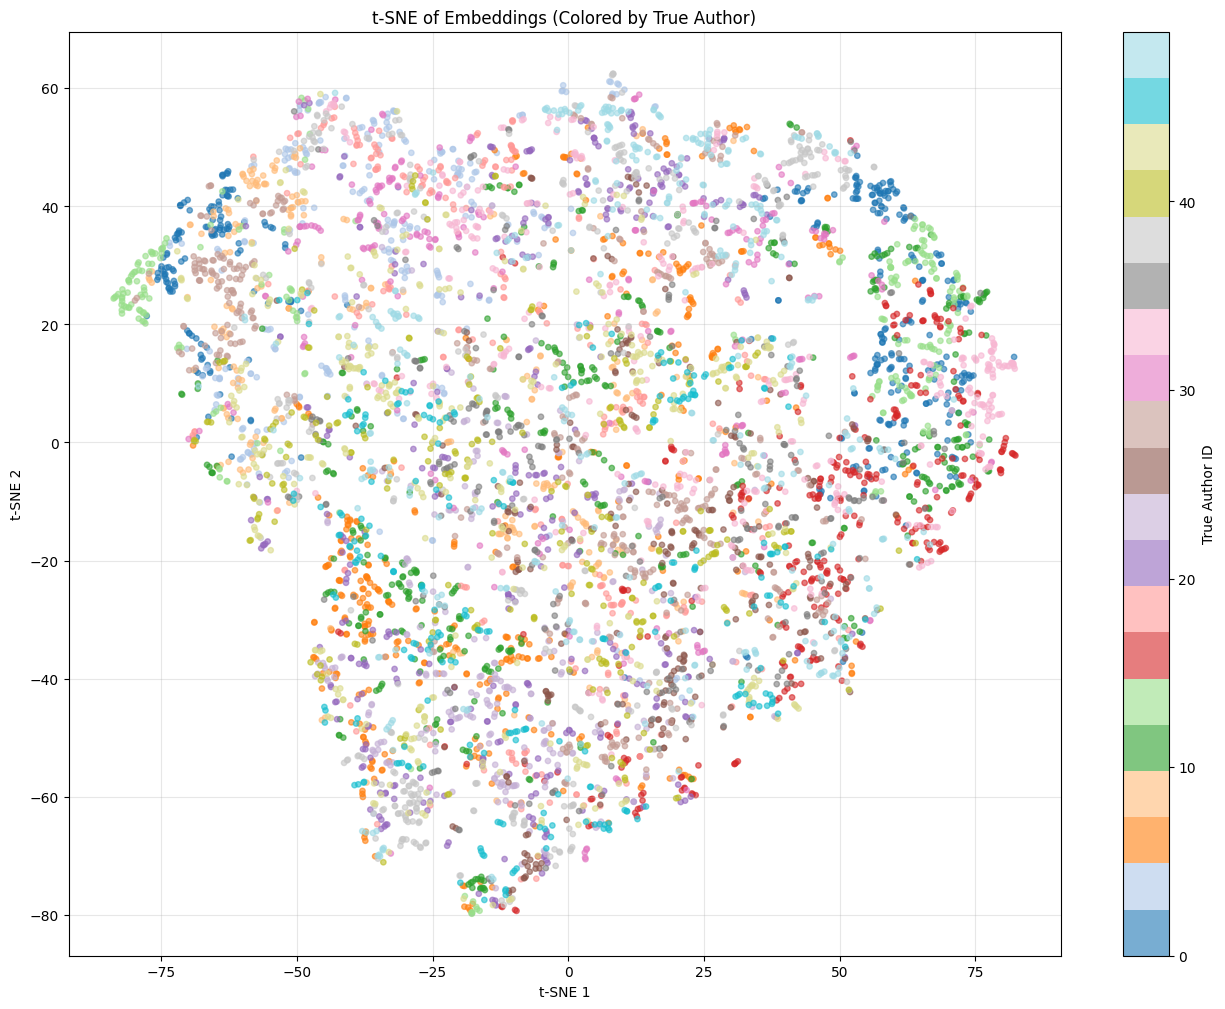

In [88]:
plt.figure(figsize=(16, 12))

scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=y_test,
    cmap="tab20",
    s=15,
    alpha=0.6,
)

plt.colorbar(scatter, label="True Author ID")
plt.title("t-SNE of Embeddings (Colored by True Author)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(alpha=0.3)
plt.show()

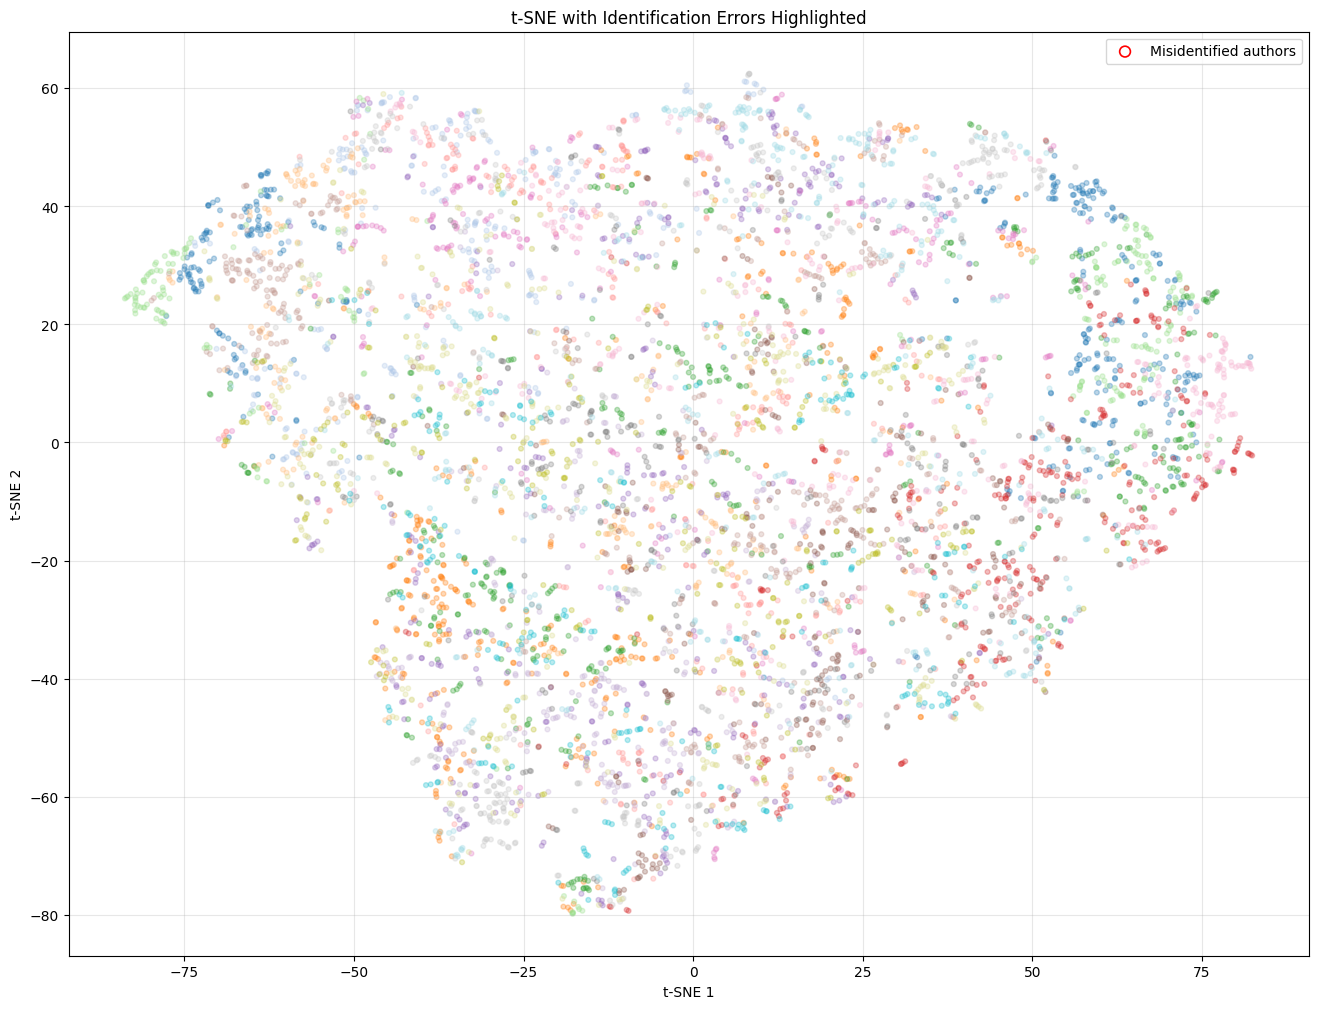

In [87]:
plt.figure(figsize=(16, 12))

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=y_test,
    cmap="tab20",
    s=12,
    alpha=0.3,
)

plt.scatter(
    embeddings_2d[is_error, 0],
    embeddings_2d[is_error, 1],
    facecolors="none",
    edgecolors="red",
    s=60,
    linewidths=1.2,
    label="Misidentified authors",
)

plt.legend()
plt.title("t-SNE with Identification Errors Highlighted")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(alpha=0.3)
plt.show()

In [61]:
len(test_results['y_true']), len(test_results['y_pred']), len(test_results['y_pred_proba'])

(6208, 6208, 6208)

In [37]:
from src.datasets import BatchResizer

resizer = BatchResizer(target_size=(60, 53))

test_data_resized = {}
for author_id, samples in subset['test'].data.items():
    resized_samples = []
    for sample in samples:
        # Ensure channel dimension
        if len(sample.shape) == 2:
            sample = np.expand_dims(sample, axis=-1)

        # Resize individual sample
        sample_resized = resizer.resize([sample])[0]
        resized_samples.append(sample_resized)

    test_data_resized[author_id] = resized_samples


In [38]:
test_results_voting = cnn_evaluator.evaluate_by_voting(
    test_data=test_data_resized,
    distance_threshold=0.52,
    min_votes=3
)

12:53:25 - siamese_cnn_evaluator - INFO - Evaluating siamese_cnn by voting...
12:53:25 - siamese_cnn_evaluator - INFO -   - Distance threshold: 0.52
12:53:25 - siamese_cnn_evaluator - INFO -   - Minimum votes: 3
12:54:27 - siamese_cnn_evaluator - INFO - Voting evaluation completed:
12:54:27 - siamese_cnn_evaluator - INFO -   - Number of authors evaluated: 50
12:54:27 - siamese_cnn_evaluator - INFO -   - Accuracy:  1.0000
12:54:27 - siamese_cnn_evaluator - INFO -   - Precision: 1.0000
12:54:27 - siamese_cnn_evaluator - INFO -   - Recall:    1.0000
12:54:27 - siamese_cnn_evaluator - INFO -   - F1-Score:  1.0000
12:54:27 - siamese_cnn_evaluator - INFO -   - Correct predictions: 50/50
12:54:27 - siamese_cnn_evaluator - INFO -   - Average confidence: 0.9387


In [39]:
embeddings_list, labels_list = [], []

for author_id, samples in test_data_resized.items():
    samples_array = np.array(samples)
    authors_embeddings = cnn_evaluator.embedding_model.predict(samples_array, verbose=0)

    embeddings_list.append(authors_embeddings)
    labels_list.extend([author_id] * len(samples))

embeddings = np.concatenate(embeddings_list, axis=0)
labels = np.array(labels_list)

In [40]:
logger.info(f"Embeddings shape: {embeddings.shape}")
logger.info(f"Unique authors: {len(np.unique(labels))}")
logger.info(f"Author IDs: {np.unique(labels)[:10]}")

INFO - Embeddings shape: (6201, 256)
INFO - Unique authors: 50
INFO - Author IDs: [0 1 2 3 4 5 6 7 8 9]


In [41]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_embeddings_tsne(
    embeddings: np.ndarray,
    labels: np.ndarray,
    title: str = "t-SNE Visualization"
  ):
    """
    Plot t-SNE visualization of embeddings.

    Args:
        embeddings: Array of embeddings (N, embedding_dim)
        labels: Array of labels (N,) - author IDs
        title: Plot title
        save_path: Path to save figure (None = show only)
    """

    logger.info(f"Computing t-SNE for {len(embeddings)} samples...")

    # Apply t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        random_state=42,
        n_iter=1000,
        verbose=0
    )
    embeddings_2d = tsne.fit_transform(embeddings)

    # Create plot
    plt.figure(figsize=(12, 8))

    # Plot each author with different color
    unique_labels = np.unique(labels)
    n_authors = len(unique_labels)

    scatter = plt.scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        c=labels,
        cmap='tab20' if n_authors <= 20 else 'viridis',
        alpha=0.6,
        s=30,
        edgecolors='none'
    )

    plt.colorbar(scatter, label='Author ID')
    plt.title(f'{title}\n{n_authors} authors, {len(embeddings)} samples', fontsize=14)
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.show()

    logger.info(f"✓ t-SNE visualization completed")


INFO - Computing t-SNE for 6201 samples...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


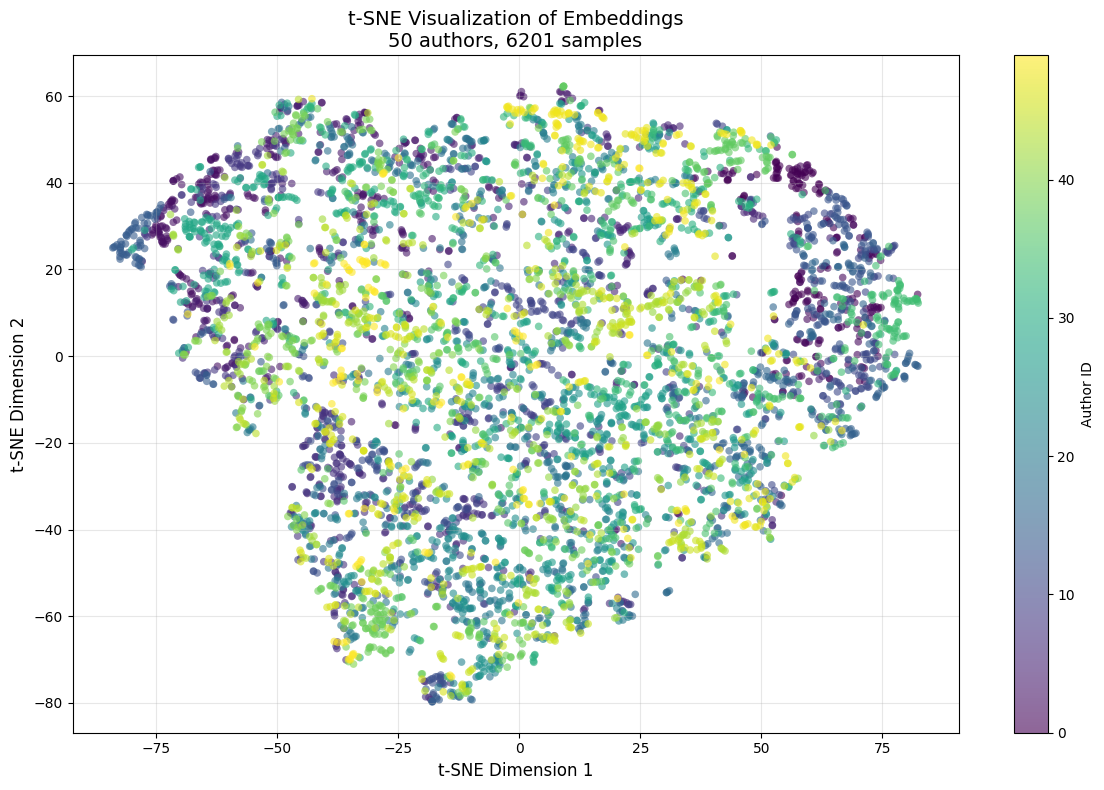

INFO - ✓ t-SNE visualization completed


In [42]:
plot_embeddings_tsne(
    embeddings=embeddings,
    labels=labels,
    title="t-SNE Visualization of Embeddings"
)

In [43]:
def plot_embeddings_tsne_by_author(
    embeddings: np.ndarray,
    labels: np.ndarray,
    title: str = "t-SNE Visualization (Author Centroids)"
):
    """
    Plot t-SNE using author centroids instead of individual samples.

    Args:
        embeddings: Individual embeddings (N, embedding_dim)
        labels: Author IDs (N,)
        title: Plot title
        save_path: Path to save
    """

    unique_authors = np.unique(labels)
    centroids = []

    for author_id in unique_authors:
        mask = labels == author_id
        author_embeddings = embeddings[mask]
        centroid = author_embeddings.mean(axis=0)
        centroids.append(centroid)

    centroids = np.array(centroids)  # (50, 256)

    logger.info(f"Computing t-SNE for {len(centroids)} author centroids...")

    tsne = TSNE(
        n_components=2,
        perplexity=min(30, len(centroids) - 1),
        random_state=42,
        n_iter=1000,
        verbose=0
    )
    centroids_2d = tsne.fit_transform(centroids)

    # Plot
    plt.figure(figsize=(12, 10))

    scatter = plt.scatter(
        centroids_2d[:, 0],
        centroids_2d[:, 1],
        c=unique_authors,
        cmap='tab20' if len(unique_authors) <= 20 else 'viridis',
        s=200,
        alpha=0.8,
        edgecolors='black',
        linewidths=1.5
    )

    for i, author_id in enumerate(unique_authors):
        plt.annotate(
            str(author_id),
            (centroids_2d[i, 0], centroids_2d[i, 1]),
            fontsize=8,
            ha='center',
            va='center'
        )

    plt.colorbar(scatter, label='Author ID')
    plt.title(f'{title}\n{len(unique_authors)} authors', fontsize=14)
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.show()
    logger.info(f"✓ t-SNE visualization completed")

INFO - Computing t-SNE for 50 author centroids...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


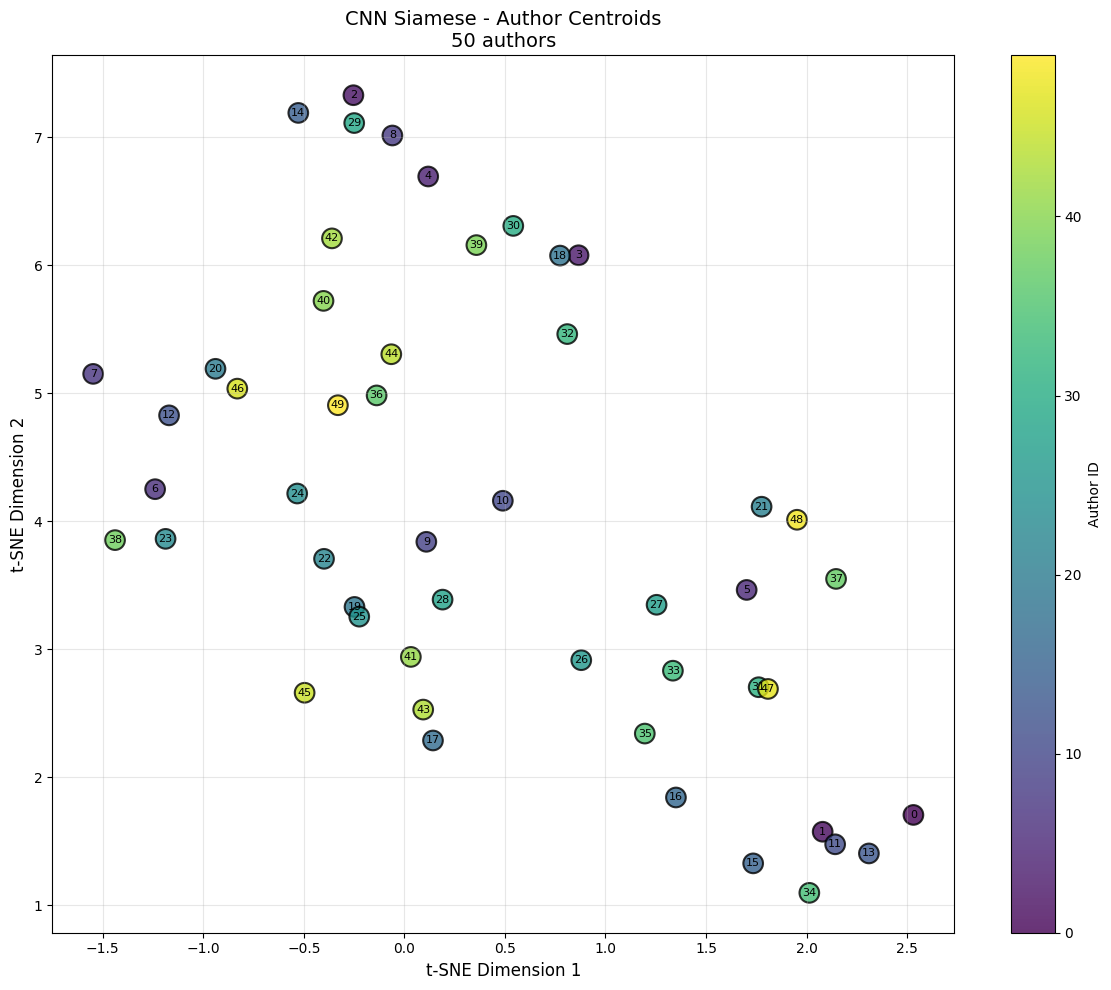

INFO - ✓ t-SNE visualization completed


In [44]:
plot_embeddings_tsne_by_author(
    embeddings=embeddings,
    labels=labels,
    title="CNN Siamese - Author Centroids",
)


In [85]:
def extract_embeddings(model, generator, num_samples=1000):
    embeddings = []
    labels = []

    count = 0
    for i in range(len(generator)):
        if count >= num_samples:
            break

        (img1, img2), label = generator[i]
        emb = model.predict([img1, img2], verbose=0)
        embeddings.append(emb[:, 0, :])
        labels.append(label)
        count += len(label)

    return np.concatenate(embeddings), np.concatenate(labels)

In [86]:
cnn_emb, cnn_labels = extract_embeddings(
    cnn_trainer.siamese_model,
    test_gen,
)

INFO - Extracting embeddings...
INFO - Embeddings shape: (6201, 256)
INFO - Number of authors: 50
INFO - Computing t-SNE... (may take 1-2 minutes)
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 6201 samples in 0.001s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 6201 samples in 0.292s...
[t-SNE] Computed conditional probabilities for sample 1000 / 6201
[t-SNE] Computed conditional probabilities for sample 2000 / 6201
[t-SNE] Computed conditional probabilities for sample 3000 / 6201
[t-SNE] Computed conditional probabilities for sample 4000 / 6201
[t-SNE] Computed conditional probabilities for sample 5000 / 6201
[t-SNE] Computed conditional probabilities for sample 6000 / 6201
[t-SNE] Computed conditional probabilities for sample 6201 / 6201
[t-SNE] Mean sigma: 0.067813
[t-SNE] KL divergence after 250 iterations with early exaggeration: 81.855774
[t-SNE] KL divergence after 1000 iterations: 1.618954


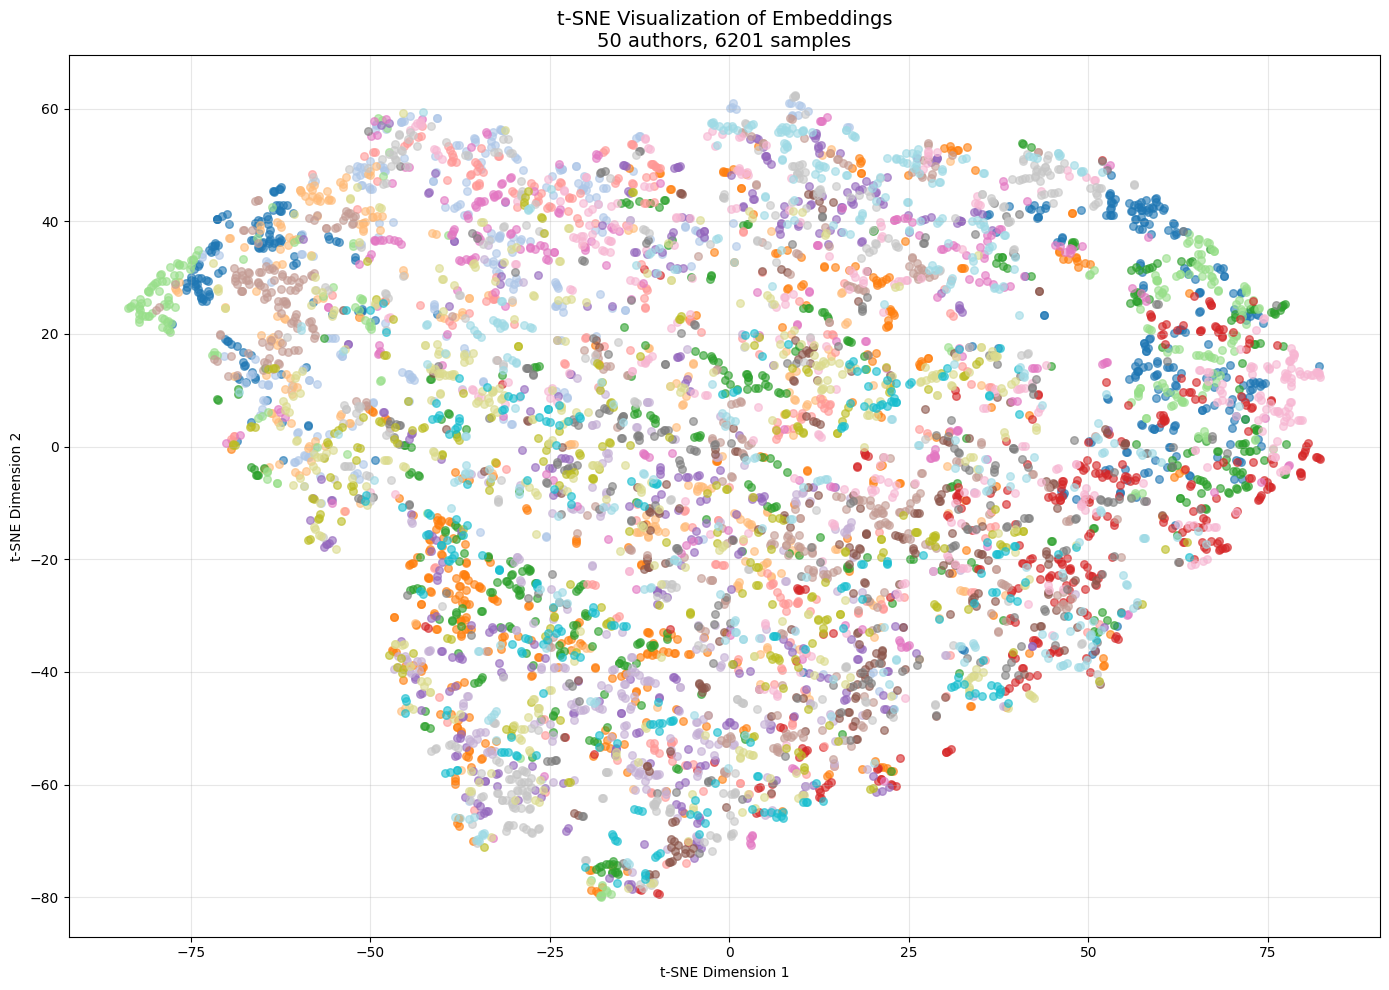

INFO - 
=== Cluster Statistics ===
INFO - Author 0: 108 samples, avg distance to centroid: 14.479
INFO - Author 1: 123 samples, avg distance to centroid: 15.512
INFO - Author 2: 131 samples, avg distance to centroid: 12.718
INFO - Author 3: 136 samples, avg distance to centroid: 25.236
INFO - Author 4: 127 samples, avg distance to centroid: 24.712


In [84]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

logger.info("Extracting embeddings...")

embeddings_list = []
labels_list = []

for author_id, samples in test_data_resized.items():
    samples_array = np.array(samples)
    author_embeddings = cnn_trainer.embedding_model.predict(samples_array, verbose=0)

    embeddings_list.append(author_embeddings)
    labels_list.extend([author_id] * len(samples))

embeddings = np.concatenate(embeddings_list, axis=0)
labels = np.array(labels_list)

logger.info(f"Embeddings shape: {embeddings.shape}")  # (N, 256)
logger.info(f"Number of authors: {len(np.unique(labels))}")

logger.info("Computing t-SNE... (may take 1-2 minutes)")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    n_iter=1000,
    verbose=1
)

embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(14, 10))

unique_authors = np.unique(labels)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_authors)))

for idx, author_id in enumerate(unique_authors):
    mask = labels == author_id
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[idx]],
        label=f'Author {author_id}',
        alpha=0.6,
        s=30
    )

plt.title(f't-SNE Visualization of Embeddings\n{len(unique_authors)} authors, {len(embeddings)} samples', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

if len(unique_authors) <= 20:
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

logger.info("\n=== Cluster Statistics ===")
for author_id in unique_authors[:5]:
    mask = labels == author_id
    author_emb = embeddings_2d[mask]
    centroid = author_emb.mean(axis=0)
    distances = np.linalg.norm(author_emb - centroid, axis=1)
    logger.info(f"Author {author_id}: {mask.sum()} samples, avg distance to centroid: {distances.mean():.3f}")


In [72]:
test_results_voting = cnn_evaluator.evaluate_by_voting(
    test_data=subset['test'].data,
    distance_threshold=0.52,
    min_votes=3
)

06:38:36 - siamese_cnn_evaluator - INFO - Evaluating siamese_cnn by voting...
06:38:36 - siamese_cnn_evaluator - INFO -   - Distance threshold: 0.52
06:38:36 - siamese_cnn_evaluator - INFO -   - Minimum votes: 3


ValueError: Input 0 of layer "siamese_cnn_embedding_model" is incompatible with the layer: expected shape=(None, 60, 53, 1), found shape=(32, 180, 160)

In [ ]:
pair_results = comparator.evaluate_all(
    test_generator=test_gen,
    distance_threshold=1.0
)

10:11:54 - model_comparator - INFO - 
Evaluating: Siamese CNN
10:11:54 - siamese_cnn_evaluator - INFO - Evaluating siamese_cnn...
10:12:48 - siamese_cnn_evaluator - INFO - Evaluation completed:
10:12:48 - siamese_cnn_evaluator - INFO -   - Accuracy:  0.5000
10:12:48 - siamese_cnn_evaluator - INFO -   - AUC:       0.6836
10:12:48 - siamese_cnn_evaluator - INFO -   - Precision: 0.5000
10:12:48 - siamese_cnn_evaluator - INFO -   - Recall:    1.0000
10:12:48 - siamese_cnn_evaluator - INFO -   - F1-Score:  0.6667
10:12:48 - model_comparator - INFO - 
Evaluating: Siamese CNN + Transformer
10:12:48 - siamese_transformer_evaluator - INFO - Evaluating siamese_transformer...
10:13:46 - siamese_transformer_evaluator - INFO - Evaluation completed:
10:13:46 - siamese_transformer_evaluator - INFO -   - Accuracy:  0.5000
10:13:46 - siamese_transformer_evaluator - INFO -   - AUC:       0.5313
10:13:46 - siamese_transformer_evaluator - INFO -   - Precision: 0.5000
10:13:46 - siamese_transformer_evaluat

In [70]:
voting_results = comparator.evaluate_all_by_voting(
    test_data=subset['test'].data,
    distance_threshold=1.0,
    min_votes=3
)

NameError: name 'comparator' is not defined

In [ ]:
best_name, best_metrics = comparator.get_best_model(metric='f1')
logger.info(f"Best model: {best_name}")
logger.info(f"  F1-Score: {best_metrics['f1']:.4f}")

10:25:46 - model_comparator - INFO - Best model by f1: Siamese CNN = 0.6667
INFO - Best model: Siamese CNN
INFO -   F1-Score: 0.6667


In [ ]:
results = comparator.evaluate_all(
    test_generator=test_gen,
    distance_threshold=1.0
)

15:15:14 - model_comparator - INFO - ============================================================
15:15:14 - model_comparator - INFO - EVALUATING MODELS
15:15:14 - model_comparator - INFO - ============================================================
15:15:16 - model_comparator - INFO - 
Evaluating: Siamese CNN
15:16:08 - model_comparator - INFO -   - Accuracy:  0.5000
15:16:08 - model_comparator - INFO -   - AUC:       0.6258
15:16:08 - model_comparator - INFO -   - Precision: 0.5000
15:16:08 - model_comparator - INFO -   - Recall:    1.0000
15:16:08 - model_comparator - INFO -   - F1-Score:  0.6667
15:16:08 - model_comparator - INFO - 
Evaluating: Siamese CNN + Transformer
15:17:03 - model_comparator - INFO -   - Accuracy:  0.5000
15:17:03 - model_comparator - INFO -   - AUC:       0.6348
15:17:03 - model_comparator - INFO -   - Precision: 0.5000
15:17:03 - model_comparator - INFO -   - Recall:    1.0000
15:17:03 - model_comparator - INFO -   - F1-Score:  0.6667
15:17:03 - model_comp

In [ ]:
best_name, best_metrics = comparator.get_best_model(metric='f1')
logger.info(f"\nBest model: {best_name}")
logger.info(f"  F1-Score: {best_metrics['f1']:.4f}")

15:17:18 - model_comparator - INFO - Best model by f1: Siamese CNN = 0.6667
INFO - 
Best model: Siamese CNN
INFO -   F1-Score: 0.6667


In [ ]:
plot_training_history(
    histories={
        'Siamese CNN': cnn_trainer.history,
        'Siamese CNN + Transformer': transformer_history
    },
    save_path=f"./results/training_curves_{current_time}.png"
)

AttributeError: 'NoneType' object has no attribute 'history'

FileNotFoundError: [Errno 2] No such file or directory: './results/comparison_metrics_20260127-143319.png'

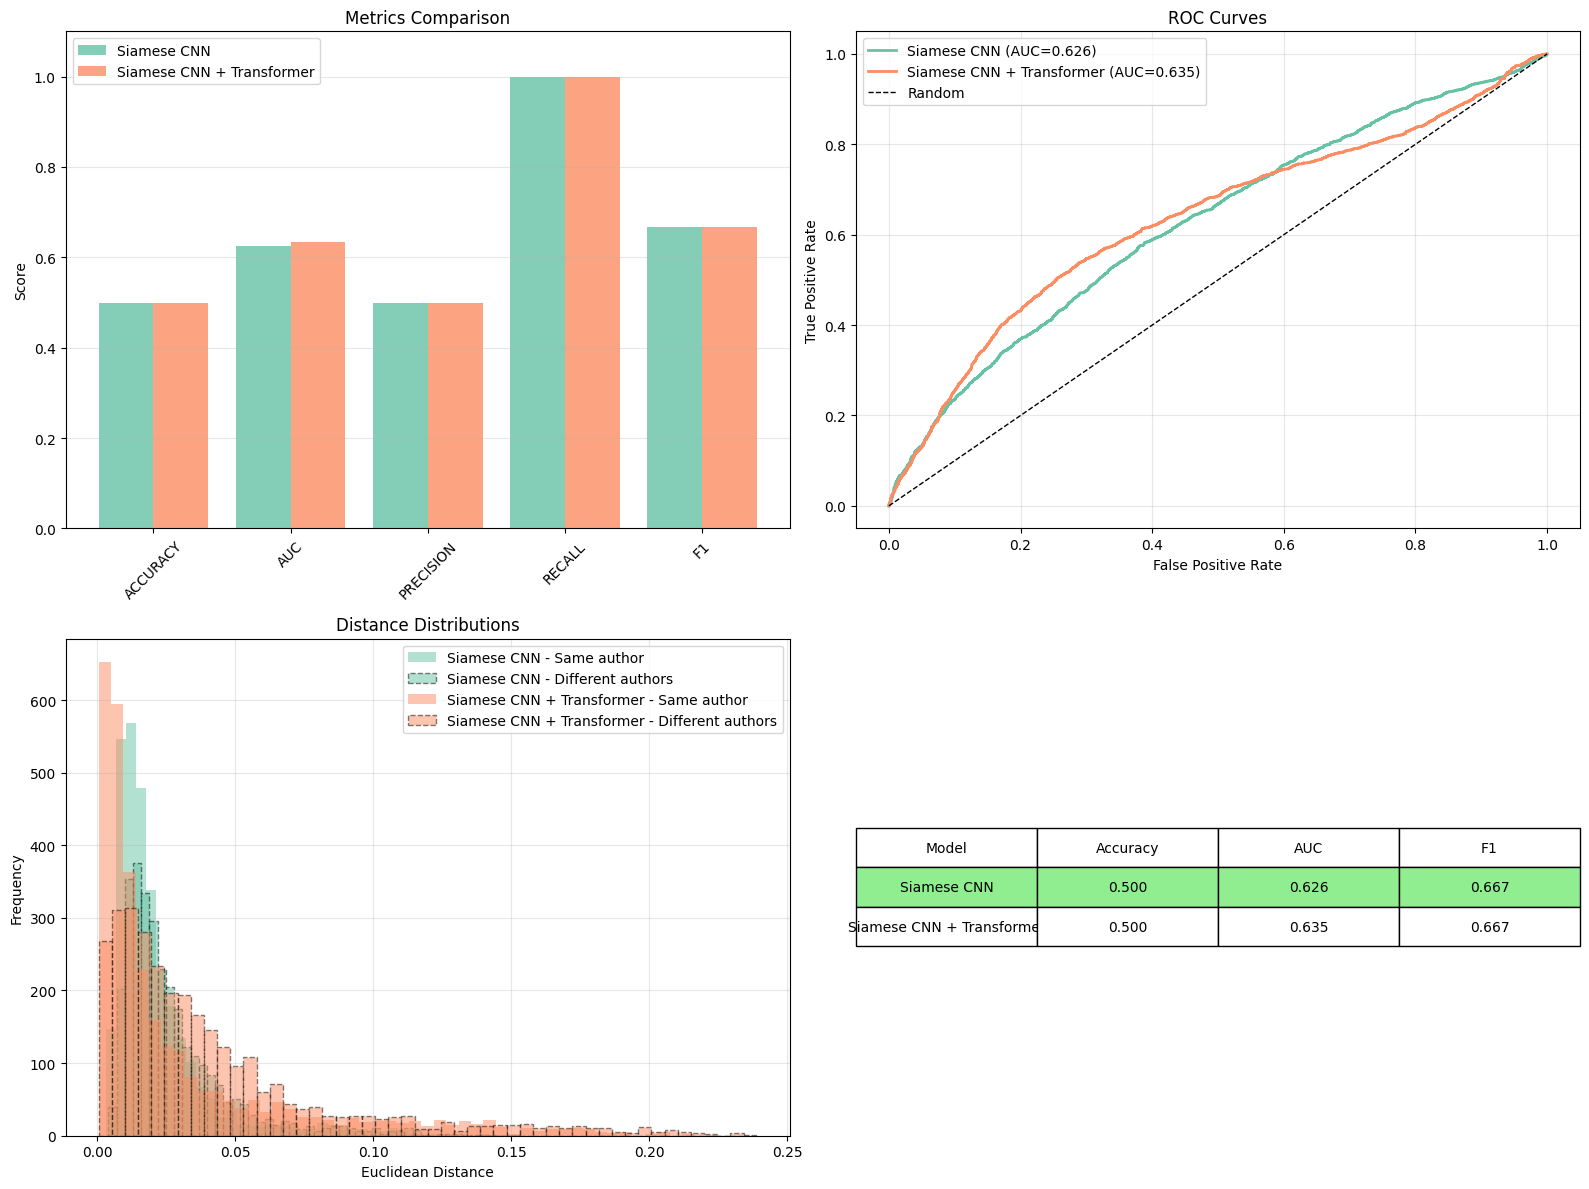

In [ ]:
plot_comparison_metrics(
    results=results,
    save_path=f"./results/comparison_metrics_{current_time}.png"
)

In [ ]:
def extract_embeddings(model, generator, num_samples=1000):
    embeddings = []
    labels = []

    count = 0
    for i in range(len(generator)):
        if count >= num_samples:
            break

        (img1, img2), label = generator[i]
        emb = model.predict([img1, img2], verbose=0)
        embeddings.append(emb[:, 0, :])
        labels.append(label)
        count += len(label)

    return np.concatenate(embeddings), np.concatenate(labels)

In [ ]:
logger.info("Extracting embeddings for visualization...")
cnn_emb, cnn_labels = extract_embeddings(
    cnn_trainer.siamese_model,
    test_gen,
)
trans_emb, trans_labels = extract_embeddings(
    transformer_trainer.siamese_model,
    test_gen,
)

INFO - Extracting embeddings for visualization...


Figure saved to: results/embeddings_tsne_20260128-081933.png


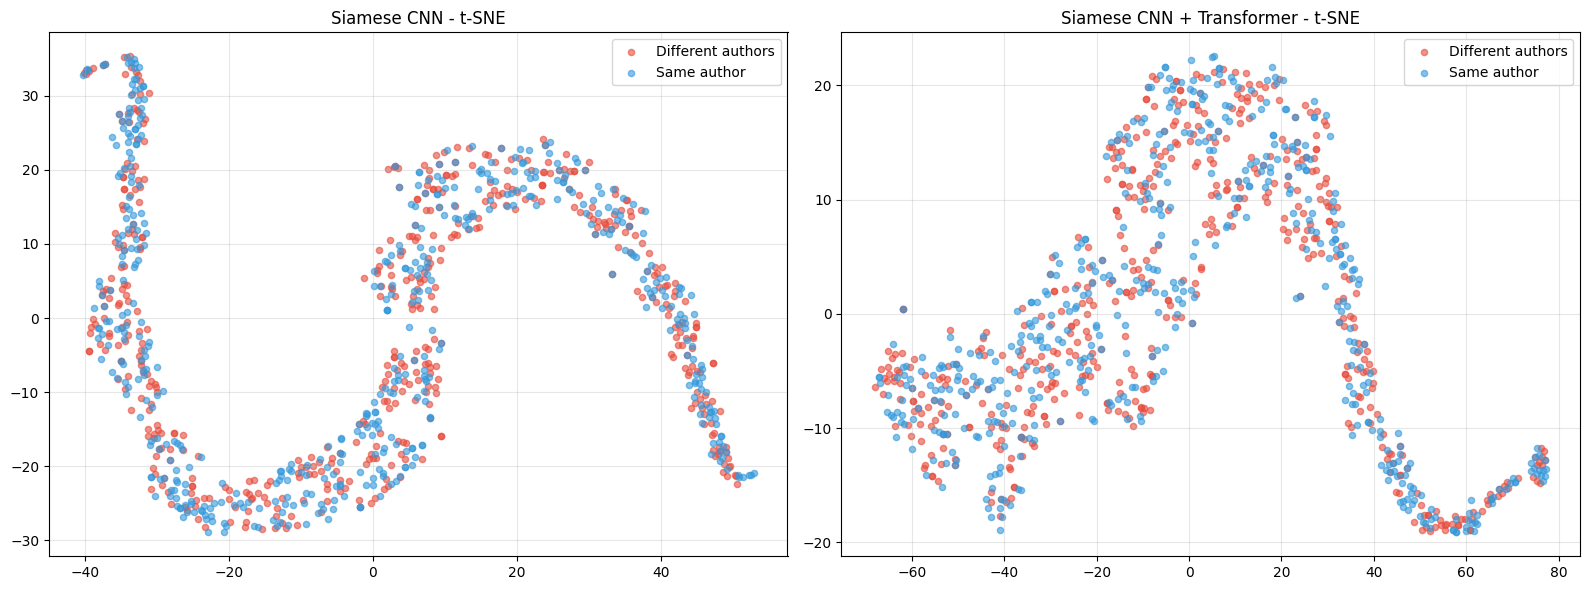

In [ ]:
plot_embeddings_tsne(
    embeddings_dict={
        'Siamese CNN': cnn_emb,
        'Siamese CNN + Transformer': trans_emb
    },
    labels_dict={
        'Siamese CNN': cnn_labels,
        'Siamese CNN + Transformer': trans_labels
    },
    save_path=f"./results/embeddings_tsne_{current_time}.png"
)

In [ ]:
model = build_embedding_model(
    backbone=backbone,
    input_shape=(60, 53, 1),
    embedding_dim=256,
    name="cnn_embedding_model"
)

In [ ]:
transformer_model = build_embedding_model(
    backbone=cnn_transformer_backbone,
    input_shape=(60, 53, 1),
    embedding_dim=256,
    name="transformer_embedding_model"
)

In [ ]:
model.summary()

Model: "cnn_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 53, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 60, 53, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 53, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 60, 53, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 26, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 30, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 13, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 15, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 7, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalize (Lambda)           │ (None, 256)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,552 (1.74 MB)

 Trainable params: 454,592 (1.73 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
transformer_model.summary()

Model: "transformer_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 60, 53, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 60, 53, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 60, 53, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 60, 53, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 30, 26, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 30, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 15, 13, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 15, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 7, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 7, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 42, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 42, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_0           │ (None, 42, 256)        │     1,315,840 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_1           │ (None, 42, 256)        │     1,315,840 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,087,232 (11.78 MB)

 Trainable params: 3,086,272 (11.77 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
siamese_model = build_siamese_model(
    embedding_model=model,
    input_shape=(60, 53, 1)
)

In [ ]:
transformer_siamese_model = build_siamese_model(
    embedding_model=transformer_model,
    input_shape=(60, 53, 1)
)

In [ ]:
siamese_model.summary()

Model: "siamese_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image1 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image2 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_embedding_model │ (None, 256)       │    455,552 │ image1[0][0],     │
│ (Functional)        │                   │            │ image2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 2, 256)    │          0 │ cnn_embedding_mo… │
│                     │                   │            │ cnn_embedding_mo… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 455,552 (1.74 MB)

 Trainable params: 454,592 (1.73 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
transformer_siamese_model.summary()

Model: "siamese_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image1 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image2 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_embedd… │ (None, 256)       │  3,087,232 │ image1[0][0],     │
│ (Functional)        │                   │            │ image2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 2, 256)    │          0 │ transformer_embe… │
│                     │                   │            │ transformer_embe… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,087,232 (11.78 MB)

 Trainable params: 3,086,272 (11.77 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
from src.models import ContrastiveLoss, BinaryCrossEntropyDistance

In [ ]:
siamese_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=ContrastiveLoss(margin=1.0)
)

In [ ]:
transformer_siamese_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=ContrastiveLoss(margin=1.0)
)

In [ ]:
history = siamese_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    verbose=1
)

Epoch 1/10
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 350s 146ms/step - loss: 0.2370 - val_loss: 0.2349
Epoch 2/10
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 350s 146ms/step - loss: 0.2352 - val_loss: 0.2284
Epoch 3/10
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 341s 142ms/step - loss: 0.2346 - val_loss: 0.2310
Epoch 4/10
 330/2402 ━━━━━━━━━━━━━━━━━━━━ 4:47 139ms/step - loss: 0.2332

KeyboardInterrupt: 

In [ ]:
history_transformer = transformer_siamese_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    verbose=1
)

Epoch 1/10
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 451s 178ms/step - loss: 0.2522 - val_loss: 0.2381
Epoch 2/10
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 423s 176ms/step - loss: 0.2364 - val_loss: 0.2325
Epoch 3/10
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 423s 176ms/step - loss: 0.2336 - val_loss: 0.2253
Epoch 4/10
  72/2402 ━━━━━━━━━━━━━━━━━━━━ 6:32 169ms/step - loss: 0.2291

KeyboardInterrupt: 

In [ ]:
from src.datasets import AuthorPartitionState

In [ ]:
def resize_batch(X: np.ndarray, target_size=(60, 53)) -> np.ndarray:
    return tf.image.resize(
        X,
        target_size,
        method="bilinear"
    ).numpy()

In [ ]:
X_test, y_test = subset['test'].flatten_data()

In [ ]:
X_test_resized = resize_batch(X_test)

In [ ]:
embeddings_test = model.predict(
    X_test_resized,
    batch_size=32,
    verbose=1
)

194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
embeddings_transformer_test = transformer_model.predict(
    X_test_resized,
    batch_size=32,
    verbose=1
)

194/194 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [ ]:
from itertools import combinations

def build_eval_pairs(
    embeddings: np.ndarray,
    labels: np.ndarray,
    max_pos_pairs_per_author: int = 50,
    neg_pos_ratio: float = 1.0,
    seed: int = 42
):
    rng = np.random.default_rng(seed)

    E1, E2, y = [], [], []

    unique_authors = np.unique(labels)
    if len(unique_authors) < 2:
        raise ValueError("Not enough authors to generate pairs")

    # Positive pairs
    pos_pairs = []
    for author in unique_authors:
        idx = np.where(labels == author)[0]
        if len(idx) < 2:
            continue

        pairs = list(combinations(idx, 2))
        rng.shuffle(pairs)
        pairs = pairs[:max_pos_pairs_per_author]

        for i, j in pairs:
            pos_pairs.append((i, j))

    if len(pos_pairs) == 0:
      raise ValueError("No positive pairs found")

    # Negative pairs
    num_neg = int(len(pos_pairs) * neg_pos_ratio)
    neg_pairs = []
    attempts = 0
    max_attempts = num_neg * 10

    while len(neg_pairs) < num_neg and attempts < max_attempts:
        a1, a2 = rng.choice(unique_authors, size=2, replace=False)
        i = rng.choice(np.where(labels == a1)[0])
        j = rng.choice(np.where(labels == a2)[0])

        neg_pairs.append((i, j))
        attempts += 1


    for i, j in pos_pairs:
        E1.append(embeddings[i])
        E2.append(embeddings[j])
        y.append(1)

    for i, j in neg_pairs:
        E1.append(embeddings[i])
        E2.append(embeddings[j])
        y.append(0)

    return np.array(E1), np.array(E2), np.array(y)

In [ ]:
E1, E2, y_pairs = build_eval_pairs(embeddings_test, y_test)

In [ ]:
E1, E2, y_pairs = build_eval_pairs(embeddings_transformer_test, y_test)

In [ ]:
logger.info(f"Unique labels in y_test: {np.unique(y_test)}")
logger.info(f"Positive pairs: {np.sum(y_pairs == 1)}")
logger.info(f"Negative pairs: {np.sum(y_pairs == 0)}")

INFO - Unique labels in y_test: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]
INFO - Positive pairs: 2500
INFO - Negative pairs: 2500


In [ ]:
logger.info(f"Unique labels in y_test: {np.unique(y_test)}")
logger.info(f"Positive pairs: {np.sum(y_pairs == 1)}")
logger.info(f"Negative pairs: {np.sum(y_pairs == 0)}")

INFO - Unique labels in y_test: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]
INFO - Positive pairs: 2500
INFO - Negative pairs: 2500


In [ ]:
distances = np.linalg.norm(E1 - E2, axis=1)

In [ ]:
distances = np.linalg.norm(E1 - E2, axis=1)

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_pairs, -distances)
roc_auc = auc(fpr, tpr)

logger.info(f"AUC: {roc_auc:.4f}")

INFO - AUC: 0.8082


In [ ]:
fnr = 1 - tpr
eer_idx = np.argmin(np.abs(fpr - fnr))
eer = fpr[eer_idx]

logger.info(f"EER: {eer:.4f}")

INFO - EER: 0.2680


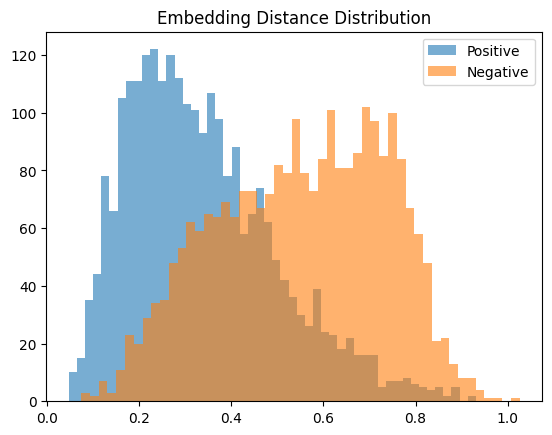

In [ ]:
import matplotlib.pyplot as plt

plt.hist(distances[y_pairs == 1], bins=50, alpha=0.6, label="Positive")
plt.hist(distances[y_pairs == 0], bins=50, alpha=0.6, label="Negative")
plt.legend()
plt.title("Embedding Distance Distribution")
plt.show()

In [ ]:
X_gallery, y_gallery = subset['test'].flatten_data()

In [ ]:
emb_gallery = mode.predict(resize_batch(X_gallery))

In [ ]:
from collections import defaultdict

gallery_by_author = defaultdict(list)
for emb, lbl in zip(emb_gallery, y_gallery):
    gallery_by_author[int(lbl)].append(emb)

gallery_by_author = {
    a: np.vstack(v) for a, v in gallery_by_author.items()
}

In [ ]:
def predict_author_from_patches(
    query_patches: np.ndarray,              # (m, H, W, C)
    gallery_by_author: dict[int, np.ndarray],
    model,
    top_q: int = 3
) -> int:
    emb_query = model.predict(
        resize_batch(query_patches),
        batch_size=32,
        verbose=0
    )

    best_author = None
    best_score = np.inf

    for author, emb_gallery in gallery_by_author.items():
        dists = (
            np.sum(emb_query**2, axis=1, keepdims=True)
            + np.sum(emb_gallery**2, axis=1)
            - 2 * emb_query @ emb_gallery.T
        )

        topq = np.partition(dists, kth=top_q-1, axis=1)[:, :top_q]
        score = float(np.mean(topq))

        if score < best_score:
            best_score = score
            best_author = author

    return best_author

In [ ]:
test_state: AuthorPartitionState = subset['test']
correct, total = 0, 0

for true_author in test_state.valid_authors:
    patches = test_state.data[true_author]

    pred = predict_author_from_patches(
        np.stack(patches, axis=0),
        gallery_by_author,
        model,
        top_q=3
    )
    correct += int(pred == true_author)
    total += 1

accuracy = correct / total
logger.info(f"Author-level accuracy: {accuracy:.4f}")